# Tutorial 2: Aligning spatial transcriptomics slices of mouse olfactory bulb

## Data Preparation

Please download the required data files from the provided link:
[Download here](https://pan.baidu.com/s/17K1cmxOPmhSvV6dG6gnafw?pwd=sjbx)

- `10X.h5ad`
- `Stereo.h5ad`

After downloading, place both files into the `datasets` folder located in the same directory as this notebook.

The folder structure should be organized as follows:

```
project_root/
│
├── datasets/
│   └── MOB/
│       ├── 10X.h5ad
│       └── Stereo.h5ad
│
├── Tutorial2_Aligning_spatial_transcriptomics_slices_of_mouse_olfactory_bulb.ipynb
│
└── SpaMOMA/
```

## import packages

In [1]:
from SpaMOMA.SpaMOMA import SpaMOMA

## Specify Slice Metadata

In [2]:
save_directory = "./SpaMOMA_output/MOB/"  
spamoma = SpaMOMA(save_dir=save_directory)
spamoma.add_slice(
    sample_id="10X",  
    raw_data_path="./datasets/MOB/10X.h5ad",  
    feature="rna"  
)
spamoma.add_slice(
    sample_id="Stereo", 
    raw_data_path="./datasets/MOB/Stereo.h5ad", 
    feature="rna"  
)
spamoma.set_reference('10X')
print(f"aligning {[sid for sid in spamoma.input_slice_dict.keys() if sid != spamoma.reference_sample_id]} to {spamoma.reference_sample_id}")

aligning ['Stereo'] to 10X


## Data Preprocessing

preprocessing rna features...


------Calculating spatial graph...
The graph contains 8295 edges, 1185 cells.
7.0000 neighbors per cell on average.


Size of Input:  (1185, 3000)


2026-02-19 23:14:57.364546: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-19 23:14:57.373564: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



100%|██████████| 500/500 [00:25<00:00, 19.89it/s]

...

------Calculating spatial graph...


The graph contains 61789 edges, 8827 cells.
7.0000 neighbors per cell on average.


Size of Input:  (8827, 3000)


2026-02-19 23:15:27.258390: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



100%|██████████| 500/500 [02:59<00:00,  2.79it/s]

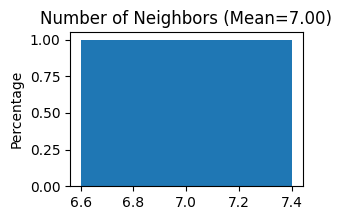

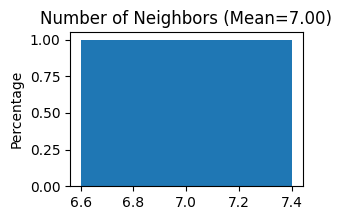

In [3]:
spamoma.preprocess_input_slices()

## Generate Spatial Pattern Images

generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


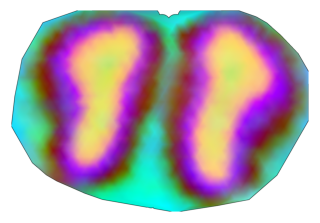

Img for 10X is saved to ./SpaMOMA_output/MOB/10X/RGB.png
generating spatial pattern image... gaussian_sigma:1.0, interpolation_method:linear, max_distance_ratio"1.2


saving image...


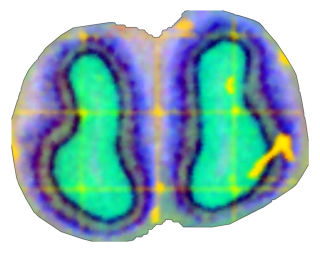

Img for Stereo is saved to ./SpaMOMA_output/MOB/Stereo/RGB.png


In [4]:
spamoma.generate_imgs()

In [5]:
spamoma.input_slice_dict

{'10X': {'sample_id': '10X',
  'raw_data_path': './datasets/MOB/10X.h5ad',
  'feature': 'rna',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars = 1185 × 3000
      obs: 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'X', 'celltype', 'batch', 'row', 'col', 'x', 'y', 'imagerow', 'imagecol', 'img_x', 'img_y', 'spot_x', 'spot_y', 'mclust', 'my_pixel_x', 'my_pixel_y'
      var: 'features', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns: 'Spatial_Net', 'hvg', 'log1p', 'mclust_colors', 'neighbors', 'umap', 'spatial_neighbors', 'moranI'
      obsm: 'STAGATE', 'X_umap', 'spatial', 'pca'
      obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances',
  'SPI_path': './SpaMOMA_output/MOB/10X/RGB.png'},
 'Stereo': {'sample_id': 'Stereo',
  'raw_data_path': './datasets/MOB/Stereo.h5ad',
  'feature': 'rna',
  'pseudo_color_key': 'pca',
  'processed_data': AnnData object with n_obs × n_vars =

## Model Training

In [6]:
spamoma.train(coarse_epochs=1000,fine_epochs=300,parallel_mode=True,coarse_gpu=1,fine_gpu=1)

start coarse adaptation...
start fine adaptation...


fine adaptation done!
coarse adaptation done!


## Slice Alignment

aligned 10X adata is saved to: ./SpaMOMA_output/MOB//alignment_output/10X.h5ad
****************** aligning Stereo to 10X ..... ******************
start coarse alignment...
match params: {'model_key': 'roma', 'match_threshold': 0.999, 'extract_max_keypoints': 4096, 'force_resize': True, 'image_height': 560, 'image_width': 560, 'choice_geometry_type': 'Homography'}
Loading Roma model: ./SpaMOMA_output/MOB/coarse_model/adapted_model_epoch_1000.pth
current Roma instance ID: 127656462648224
preprocessing is already resized
Force resize to 560x560


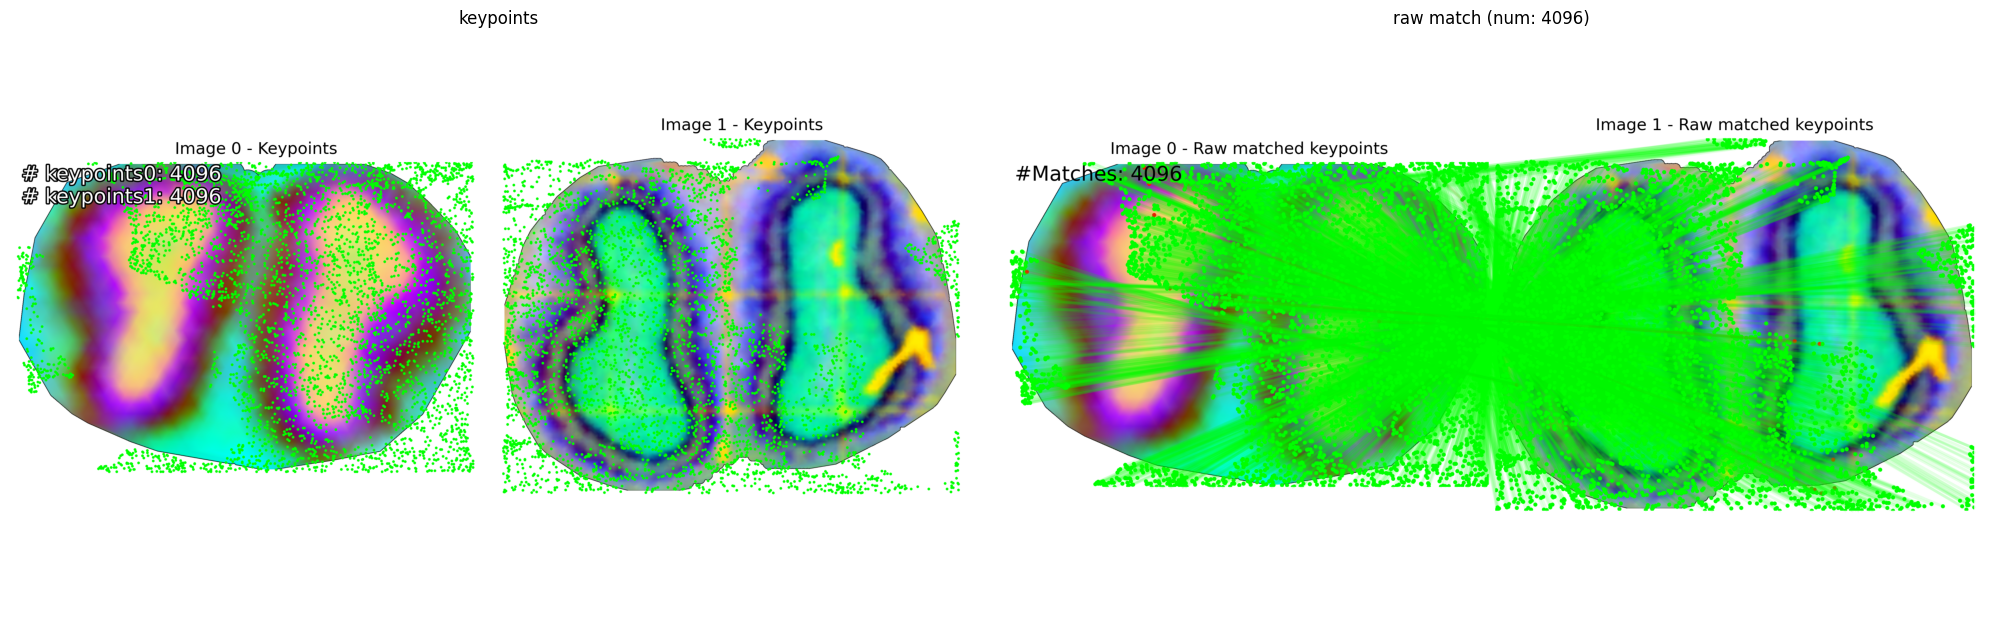


Matching statistics:
- Number of raw match points: 4096
coarse alignment done!
start fine alignment...
Loading Roma model: ./SpaMOMA_output/MOB/fine_model/adapted_model_epoch_300.pth
current Roma instance ID: 127655798812576
preprocessing is already resized
Force resize to 560x560


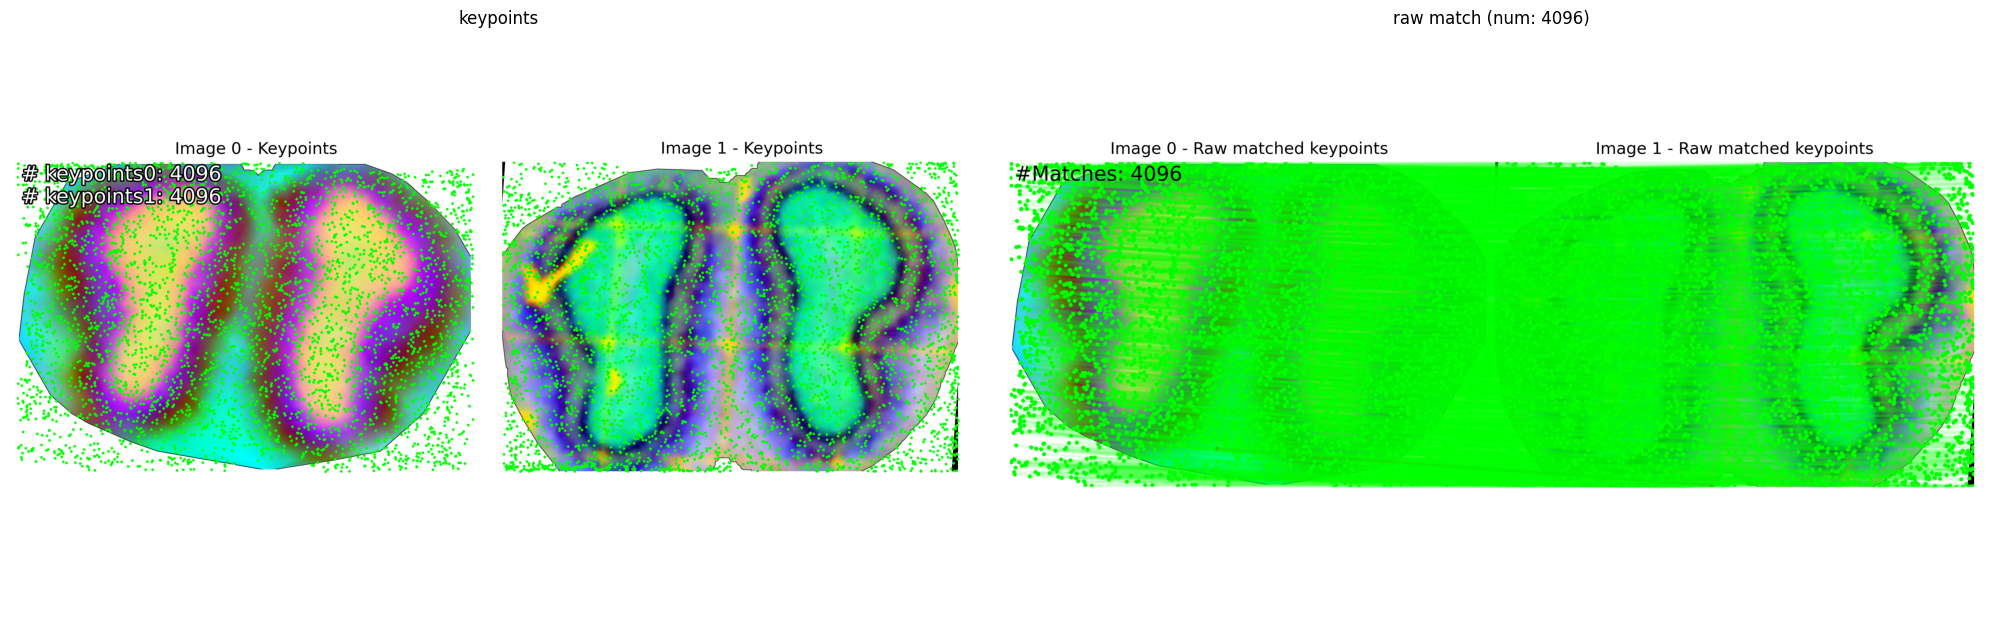


Matching statistics:
- Number of raw match points: 4096


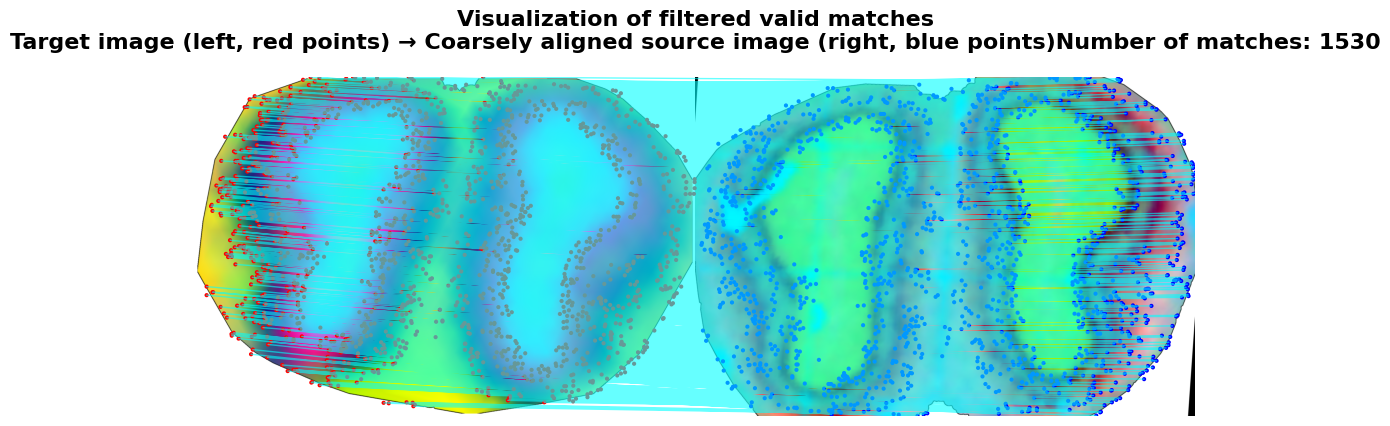

aligned Stereo adata is saved to: ./SpaMOMA_output/MOB//alignment_output/Stereo.h5ad
fine alignment done!


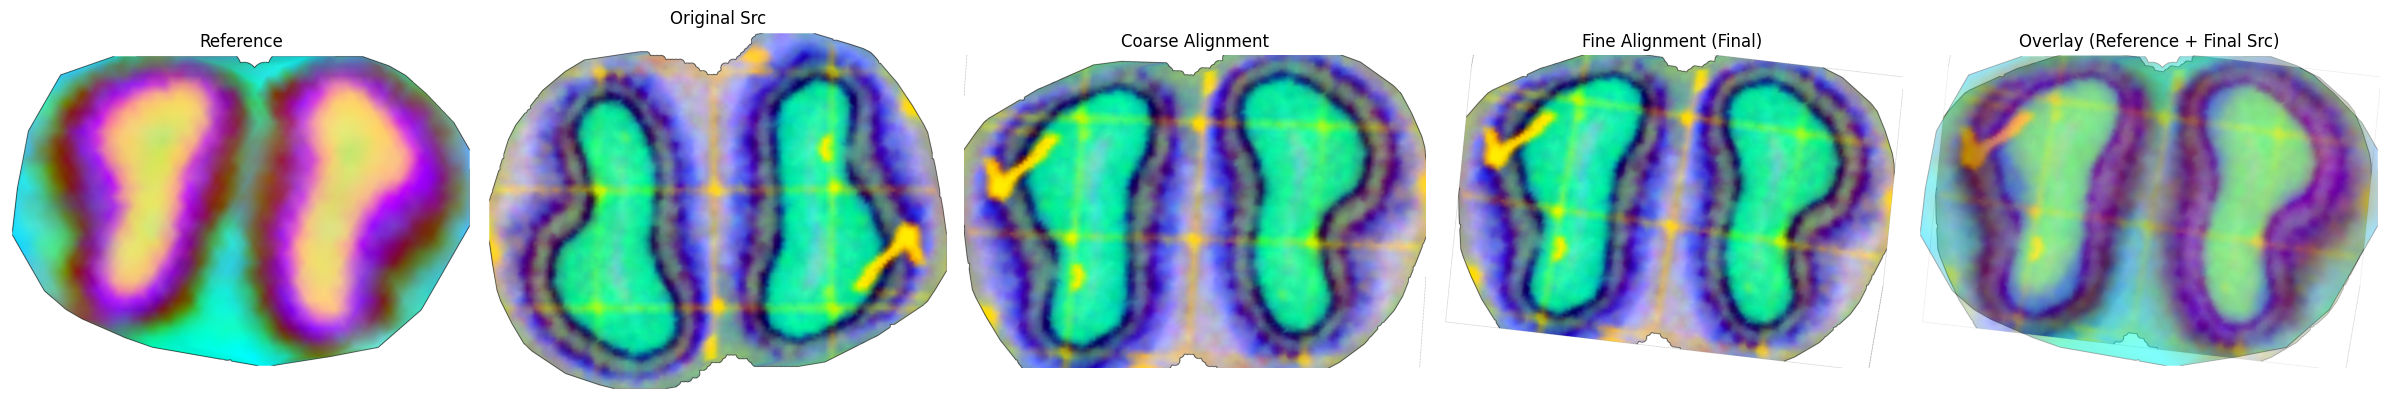

In [ ]:
spamoma.align_slices(visualize_correspondences=True)